In [15]:
import csv

# File paths
input_file = "/home/sylas/Desktop/DSR/dsr-competition/data/raw/train.csv"
output_file = "/home/sylas/Desktop/DSR/dsr-competition/data/cleaned/item_10350_train.csv"
target_item = "10350"  # Target item_nbr as a string

print("Filte train.csv line-by-line...")

match_count = 0

# Open input file for reading and output file for writing
with open(input_file, mode="r", encoding="utf-8") as infile, open(
    output_file, mode="w", encoding="utf-8", newline=""
) as outfile:

  reader = csv.reader(infile)
  writer = csv.writer(outfile)

  # Read header line
  header = next(reader)
  writer.writerow(header)  # Write header to new file

  # Find which column contains 'item_nbr'
  item_col_idx = header.index("item_nbr")

  # Loop through rows one by one
  for row in reader:
    if row[item_col_idx] == target_item:
      writer.writerow(row)
      match_count += 1

print(
    f"Done! Saved {match_count} rows for item {target_item} to '{output_file}'."
)

Filte train.csv line-by-line...
Done! Saved 0 rows for item 10350 to '/home/sylas/Desktop/DSR/dsr-competition/data/cleaned/item_10350_train.csv'.


In [16]:
import pandas as pd

# Load only your item's pre-filtered CSV
df_item_10350 = pd.read_csv(
    "/home/sylas/Desktop/DSR/dsr-competition/data/cleaned/item_96995_train.csv"
)
print(df_item_10350.info())
print(df_item_10350.head())

<class 'pandas.DataFrame'>
RangeIndex: 5229 entries, 0 to 5228
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           5229 non-null   int64  
 1   date         5229 non-null   str    
 2   store_nbr    5229 non-null   int64  
 3   item_nbr     5229 non-null   int64  
 4   unit_sales   5229 non-null   float64
 5   onpromotion  1274 non-null   object 
dtypes: float64(1), int64(3), object(1), str(1)
memory usage: 296.3+ KB
None
       id        date  store_nbr  item_nbr  unit_sales onpromotion
0  196657  2013-01-06         44     96995         1.0         NaN
1  207764  2013-01-07          2     96995         2.0         NaN
2  236538  2013-01-07         44     96995         1.0         NaN
3  275800  2013-01-08         44     96995         1.0         NaN
4  282601  2013-01-08         50     96995         2.0         NaN


In [17]:
# 1. Load CSVs and change titles
df_item10350 = pd.read_csv("../data/cleaned/item_10350_train.csv")

df_items = pd.read_csv("../data/raw/items.csv")
df_items.rename(columns={"class": "Item_Class", "family": "Item_Family"}, inplace=True)

df_stores = pd.read_csv("../data/raw/stores.csv")
df_stores.rename(columns={"cluster": "Store_Cluster", "type": "Store_Type"}, inplace=True)

df_holidays = pd.read_csv("../data/raw/holidays_events.csv")

df_oil = pd.read_csv("../data/raw/oil.csv")
df_oil.rename(columns={"dcoilwtico": "Oil_Price"}, inplace=True)

#  Merge item details on 'item_nbr'
df_10350_merged = pd.merge(df_item10350, df_items, on="item_nbr", how="left")

# 4. Merge store details on 'store_nbr'
df_merged = pd.merge(df_10350_merged, df_stores, on="store_nbr", how="left")
df_merged = pd.merge(df_merged, df_holidays, on="date", how="left")
df_merged = pd.merge(df_merged, df_oil, on="date", how="left")

# 5. Save the complete merged dataset to a new CSV file
df_merged.to_csv("../data/cleaned/item_10350_merged.csv", index=False)

print(f"Successfully merged! Saved complete file to: ../data/cleaned/item_10350_merged.csv")
print(f"New dataset shape: {df_merged.shape}\n")

df_merged.info()
df_merged.head()

Successfully merged! Saved complete file to: ../data/cleaned/item_10350_merged.csv
New dataset shape: (0, 19)

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             0 non-null      object 
 1   date           0 non-null      object 
 2   store_nbr      0 non-null      object 
 3   item_nbr       0 non-null      object 
 4   unit_sales     0 non-null      object 
 5   onpromotion    0 non-null      object 
 6   Item_Family    0 non-null      str    
 7   Item_Class     0 non-null      int64  
 8   perishable     0 non-null      int64  
 9   city           0 non-null      str    
 10  state          0 non-null      str    
 11  Store_Type     0 non-null      str    
 12  Store_Cluster  0 non-null      int64  
 13  type           0 non-null      str    
 14  locale         0 non-null      str    
 15  locale_name    0 non-null      str    
 16  descriptio

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,Item_Family,Item_Class,perishable,city,state,Store_Type,Store_Cluster,type,locale,locale_name,description,transferred,Oil_Price


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the merged dataset
df = pd.read_csv("../data/cleaned/item_96995_merged.csv")

# Fix onpromotion: convert booleans/strings/missing values to 0 and 1
df["onpromotion"] = df["onpromotion"].map({True: 1, False: 0, "True": 1, "False": 0}).fillna(0).astype(int)
df["Oil_Price"] = df["Oil_Price"].ffill().bfill()
df["is_holiday"] = df["locale"].notna().astype(int)  # 1 if holiday, 0 if not

# Fix date: parse as datetime and extract numeric time features
df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month


# Encode categorical variables as numeric codes for correlation
df["Item_Family"] = df["Item_Family"].astype("category").cat.codes
df["Item_Class"] = df["Item_Class"].astype("category").cat.codes
df["Store_Type"] = df["Store_Type"].astype("category").cat.codes
df["city"] = df["city"].astype("category").cat.codes
df["state"] = df["state"].astype("category").cat.codes

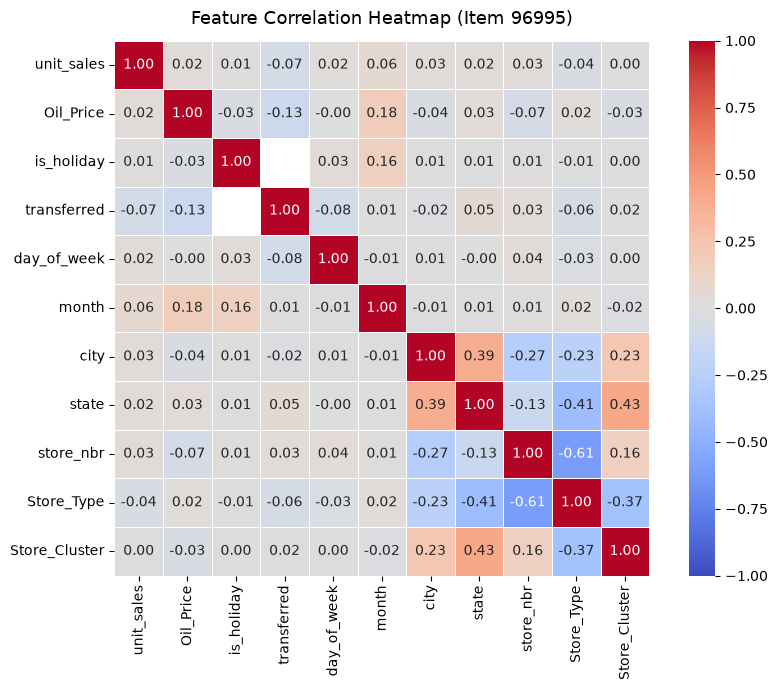

In [20]:
features = [
    "unit_sales",
    "Oil_Price",
    "is_holiday",
    "transferred",
    "day_of_week",
    "month",
    "city",
    "state",
    "store_nbr",
    "Store_Type",
    "Store_Cluster",
]

corr_matrix = df[features].corr()


# Plot heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap (Item 96995)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [16]:
#remove highly correlated columns

high_corr = ['1stFlrSF','YearRemodAdd','MoSold','ScreenPorch','OpenPorchSF','HalfBath']

x_train = x_train.drop(high_corr,axis=1)